# Palmer Lab — Cyanobacteria Field Survey: Sample Location Map

light-quality map of all **109 water samples** collected across **17 US states** during 4 field expeditions.

### Quick start
1. Set `ENCODING` in the **Configuration** cell below to choose what the point colors represent
2. Set `STYLE` to `"light"` (white bg) or `"dark"` (black bg)
3. Run all cells (`Cell → Run All`)
4. Optionally set `SAVE_PATH` to export a high-resolution PDF/PNG

### Available encodings

| `ENCODING` value | What is visualized | Best for |
|---|---|---|
| `"type"` | Water body type (Lake, River, Hot Springs, …) | Habitat diversity overview |
| `"expedition"` | Field expedition (0–3, colored by trip) | Field campaign timeline |
| `"temperature"` | Water temperature (°C, blue→red gradient) | Thermal gradient across sites |
| `"ph"` | pH (yellow=acidic → green=neutral → purple=alkaline) | Water chemistry gradient |
| `"salinity"` | Salinity (% ) | Fresh→marine continuum |
| `"altitude"` | Collection altitude (ft) | Elevation gradient |
| `"hypothesis"` | User-supplied hypothesis scores (green = 1.0 → red = 0) | Hypothesis scoring overlay |

> **Tip:** Samples with no data for the chosen encoding are shown as small gray circles.


In [81]:
# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit these values to change the map
# ════════════════════════════════════════════════════════════════════════════

ENCODING    = "hypothesis"          # "type" | "expedition" | "temperature" | "ph" | "salinity" | "altitude" | "hypothesis"
TEMP_UNIT   = "C" # ("F" or "C")
STYLE       = "dark"  # "light" | "dark"

POINT_SIZE   = 85    # marker area in pt² (increase for larger dots)
POINT_ALPHA  = 0.92  # marker opacity 0–1
SHOW_STATE_LABELS = True   # label sampled states with their 2-letter abbreviation
SHOW_SCALEBAR     = True   # draw a scale bar   # "C" | "F"  — temperature encoding unit
TEMP_FIXED_RANGE = True    # True = fix colorbar to full 0–80°C / 32–176°F range; False = auto-range from data

# Hypothesis overlay settings
HYPOTHESIS_FILE = "notebooks/CyanoSurvival.csv"  # relative to project root; e.g. "Maps/hypothesis_scores.txt" or a full path to a text file
HYPOTHESIS_ID_COL = "SampleID"  # column name for sample IDs in the hypothesis file
HYPOTHESIS_SCORE_COL = "Hypothesis"  # column name for hypothesis scores in the hypothesis file
HYPOTHESIS_CMAP = "RdYlGn"  # green (1.0) → yellow → red (0)

# Set a path to save the figure (e.g. "figures/map.pdf" or "figures/map.png")
if ENCODING == "temperature":
    FILE_NAME = f"MAP_{ENCODING}_{TEMP_UNIT}_{STYLE}"
else: 
    FILE_NAME = f"MAP_{ENCODING}_{STYLE}"

# Set to None to skip saving
SAVE_PATH = f"Maps/{FILE_NAME}.pdf"  # example: "figures/sample_map.pdf"

In [82]:
import ast
import warnings
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Resolve project root relative to this notebook
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "notebooks").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = (
    PROJECT_ROOT.parent.parent.parent
    / "Field_Trips" / "Field_Logs" / "Cyano_FieldSamplesLog_All.csv"
)
print(f"Data path: {DATA_PATH}")
print(f"Exists: {DATA_PATH.exists()}")


# ── Custom temperature colormap: blue → yellow → red (no white) ──
_temp_cmap = mcolors.LinearSegmentedColormap.from_list(
    'BlYlRd',
    ['#2166ac', '#4393c3', '#92c5de', '#f7ef52', '#fdb863', '#e08214', '#b35806'],
)
plt.colormaps.register(_temp_cmap, name='BlYlRd', force=True)

# ── Hypothesis colormap helper ───────────────────────────────────────────

def _normalize_sample_id(values):
    values = values.astype(str).str.strip()
    values = values.str.replace(r"\s+", "", regex=True)
    values = values.str.replace(r"[^A-Za-z0-9]", "", regex=True)
    values = values.str.replace(r"([A-Za-z])1$", r"\1", regex=True)
    values = values.str.replace(
        r"([A-Za-z]+)(\d{5})([A-Za-z])$",
        lambda m: m.group(1) + "0" + m.group(2) + m.group(3),
        regex=True,
    )
    return values


def _prepare_hypothesis_scores(gdf_in: gpd.GeoDataFrame, hypothesis_file: str | None):
    """Load hypothesis scores and merge onto the sample GeoDataFrame.

    Expected input file format:
        SampleID    Hypothesis
        sample_a    1.0
        sample_b    0.25
    """
    if hypothesis_file is None:
        return None

    path = Path(hypothesis_file)
    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(f"Hypothesis file not found: {path}")

    # Handle whitespace-delimited or tab-delimited text files.
    if path.suffix.lower() in {".csv", ".tsv", ".txt"}:
        sep = "," if path.suffix.lower() == ".csv" else "\\t"
        try:
            scores = pd.read_csv(path, sep=sep)
        except Exception:
            scores = pd.read_csv(path, sep=None, engine="python")
    else:
        raise ValueError("Hypothesis file must be a .csv, .tsv, or .txt file")

    print(f"Loaded hypothesis file: {path}")
    print("Hypothesis columns:", list(scores.columns))
    print(scores.head().to_string(index=False))

    scores.columns = [c.strip() for c in scores.columns]
    id_col = next((c for c in scores.columns if c.lower() == HYPOTHESIS_ID_COL.strip().lower()), None)
    score_col = next((c for c in scores.columns if c.lower() == HYPOTHESIS_SCORE_COL.strip().lower()), None)

    if id_col is None or score_col is None:
        raise KeyError(
            f"Hypothesis file must contain columns matching '{HYPOTHESIS_ID_COL}' and '{HYPOTHESIS_SCORE_COL}'. "
            f"Found: {list(scores.columns)}"
        )

    scores = scores[[id_col, score_col]].copy()
    scores = scores.rename(columns={id_col: "SampleID", score_col: "Hypothesis"})
    scores["SampleID"] = _normalize_sample_id(scores["SampleID"])
    scores["Hypothesis"] = pd.to_numeric(scores["Hypothesis"], errors="coerce")
    scores = scores.dropna(subset=["Hypothesis"])

    if scores.empty:
        raise ValueError("No valid hypothesis scores were found in the hypothesis file")

    merged = gdf_in.copy()
    if "Hypothesis" in merged.columns:
        merged = merged.drop(columns=["Hypothesis"])
    merged["SampleID"] = _normalize_sample_id(merged["SampleID"])

    merged = merged.merge(scores, on="SampleID", how="left")

    if merged["Hypothesis"].isna().all():
        print("No sample IDs matched after normalization; falling back to row-wise alignment.")
        merged = gdf_in.copy()
        if "Hypothesis" in merged.columns:
            merged = merged.drop(columns=["Hypothesis"])
        merged["SampleID"] = _normalize_sample_id(merged["SampleID"])
        merged["Hypothesis"] = scores["Hypothesis"].iloc[:len(merged)].to_numpy()

    print("Sample IDs in hypothesis file:", scores["SampleID"].head().tolist())
    print("Sample IDs in map data:", merged["SampleID"].head().tolist())
    print("Merged hypothesis columns:", list(merged.columns))
    return merged

Data path: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/Field_Trips/Field_Logs/Cyano_FieldSamplesLog_All.csv
Exists: True


/var/folders/cr/9y9g3zs15tn8hr54m5nn72200000gn/T/ipykernel_64543/3722921473.py:36: UserWarning: Overwriting the cmap 'BlYlRd' that was already in the registry.
  plt.colormaps.register(_temp_cmap, name='BlYlRd', force=True)


### The cell below expects an excel sheet with location as a single column in the format [latitude, longitude].

In [83]:
df = pd.read_excel(DATA_PATH)

# Parse "[lat, lon]" coordinate strings
df["lat"] = df["Coordinates"].apply(lambda x: ast.literal_eval(x)[0])
df["lon"] = df["Coordinates"].apply(lambda x: ast.literal_eval(x)[1])

# Temperature unit conversion
df["Fahrenheit"] = df["Celsius"] * 9 / 5 + 32
TEMP_COL   = "Fahrenheit" if TEMP_UNIT == "F" else "Celsius"
TEMP_LABEL = f"Water Temperature (°{TEMP_UNIT})"
TEMP_RANGE = (32, 176) if TEMP_UNIT == "F" else (0, 80)

# Build GeoDataFrame (WGS-84)
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326"
)

# Ensure sample IDs are available for hypothesis-based overlay
if "SampleID" not in gdf.columns:
    sample_id_col = None
    for candidate in ["ID", "SampleID", "Sample", "sample_id", "sample", "Sample Name", "sample_name", "SampleNo", "sample_no"]:
        if candidate in gdf.columns:
            sample_id_col = candidate
            break
    if sample_id_col is None:
        gdf["SampleID"] = np.arange(len(gdf)).astype(str)
    else:
        gdf["SampleID"] = gdf[sample_id_col].astype(str)

print(f"Loaded {len(gdf)} samples across {df['State'].nunique()} states")
print(f"Expeditions: {sorted(df['Expedition'].unique())}")
print(f"Water types ({df['Type'].nunique()}): {sorted(df['Type'].dropna().unique())}")
print()
print("Metadata completeness:")
for col in ["Celsius", "pH", "PercentSalinity", "Altitude (feet)"]:
    n_valid = df[col].notna().sum()
    print(f"  {col:25s}: {n_valid}/{len(df)} ({100*n_valid/len(df):.0f}%)")


Loaded 109 samples across 17 states
Expeditions: [0, 1, 2, 3]
Water types (20): ['Bay', 'Biocrust', 'Cave Pool', 'Cave River', 'Creek', 'Estuary', 'Everglades', 'Flowage', 'Hot Springs', 'Lagoon', 'Lake', 'Marsh', 'Moat', 'Outflow', 'Pond', 'Pool', 'Reservoir', 'River', 'Spring', 'Waterfall']

Metadata completeness:
  Celsius                  : 104/109 (95%)
  pH                       : 64/109 (59%)
  PercentSalinity          : 109/109 (100%)
  Altitude (feet)          : 109/109 (100%)


In [84]:
# Geographic data from Natural Earth (50m resolution)
# Files are cached by geopandas after first download (~10 MB total)
GEO_CACHE = PROJECT_ROOT / ".geo_cache"
GEO_CACHE.mkdir(exist_ok=True)

def _cached_read(url: str, name: str) -> gpd.GeoDataFrame:
    cache_file = GEO_CACHE / name
    if cache_file.exists():
        return gpd.read_file(cache_file)
    print(f"  Downloading {name}...")
    gdf_tmp = gpd.read_file(url)
    gdf_tmp.to_file(cache_file)
    return gdf_tmp

print("Loading geographic layers...")
states    = _cached_read("https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_1_states_provinces.zip",   "ne_states.gpkg")
countries = _cached_read("https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip",          "ne_countries.gpkg")
lakes     = _cached_read("https://naciscdn.org/naturalearth/50m/physical/ne_50m_lakes.zip",                      "ne_lakes.gpkg")
ocean     = _cached_read("https://naciscdn.org/naturalearth/50m/physical/ne_50m_ocean.zip",                      "ne_ocean.gpkg")
rivers    = _cached_read("https://naciscdn.org/naturalearth/50m/physical/ne_50m_rivers_lake_centerlines.zip",    "ne_rivers.gpkg")

# Subset to relevant features
us_states   = states[states["admin"] == "United States of America"].copy()
na_context  = countries[countries["ADMIN"].isin(
    ["United States of America", "Canada", "Mexico"]
)].copy()

# Project everything to EPSG:5070 Albers Equal Area (CONUS standard)
AEA = "EPSG:5070"
us_states_p  = us_states.to_crs(AEA)
na_context_p = na_context.to_crs(AEA)
lakes_p      = lakes.to_crs(AEA)
ocean_p      = ocean.to_crs(AEA)
rivers_p     = rivers.to_crs(AEA)
gdf_p        = gdf.to_crs(AEA)

# Only label states that were actually sampled
sampled_state_abbrevs = set(df["State"].dropna())
state_labels = us_states_p[us_states_p["iso_3166_2"].str[-2:].isin(sampled_state_abbrevs)].copy()
state_labels["abbrev"] = state_labels["iso_3166_2"].str[-2:]
state_labels["cx"] = state_labels.geometry.centroid.x
state_labels["cy"] = state_labels.geometry.centroid.y

# Manual centroid nudges for states with odd shapes
_nudges = {
    "FL": (150_000, -150_000),
    "MI": (200_000, -100_000),
    "LA": (0, -80_000),
}
for abbrev, (dx, dy) in _nudges.items():
    mask = state_labels["abbrev"] == abbrev
    state_labels.loc[mask, "cx"] += dx
    state_labels.loc[mask, "cy"] += dy

print("Geographic layers ready.")


Loading geographic layers...
Geographic layers ready.


In [85]:
# ── Water type colors ──────────────────────────────────────────────────────
TYPE_COLORS = {
    # Standing water — blues
    "Lake":        "#2196F3",
    "Pond":        "#64B5F6",
    "Reservoir":   "#1565C0",
    "Flowage":     "#42A5F5",
    # Flowing water — teals
    "River":       "#00BCD4",
    "Creek":       "#26C6DA",
    "Waterfall":   "#00E5FF",
    "Outflow":     "#80DEEA",
    # Coastal / marine
    "Bay":         "#1A237E",
    "Estuary":     "#006064",
    "Lagoon":      "#00897B",
    # Wetlands / special aquatic
    "Marsh":       "#4CAF50",
    "Everglades":  "#2E7D32",
    # Thermal
    "Spring":      "#FF9800",
    "Hot Springs": "#F44336",
    # Cave
    "Cave River":  "#7B1FA2",
    "Cave Pool":   "#CE93D8",
    # Urban / artificial
    "Pool":        "#B3E5FC",
    "Moat":        "#90A4AE",
    # Terrestrial
    "Biocrust":    "#8D6E63",
}

# ── Expedition labels & colors ─────────────────────────────────────────────
EXPEDITION_COLORS = {
    0: "#E91E63",
    1: "#FF9800",
    2: "#4CAF50",
    3: "#2196F3",
}
EXPEDITION_LABELS = {
    0: "Pilot — Chicago (Jul 2024)",
    1: "Exp. 1 — Great Lakes & Upper Midwest (Sep 2024)",
    2: "Exp. 2 — Appalachian & Southeast (Sep–Oct 2024)",
    3: "Exp. 3 — Pacific Coast & Southwest (Sep 2025)",
}

# ── Continuous encodings (column, colormap, label) ─────────────────────────
CONTINUOUS = {
    "temperature": (TEMP_COL, "BlYlRd", TEMP_LABEL, TEMP_RANGE if TEMP_FIXED_RANGE else None),
    "ph":          ("pH",                "RdYlGn",   "pH",                    None),
    "salinity":    ("PercentSalinity",   "YlOrRd",   "Salinity (%)",          None),
    "altitude":    ("Altitude (feet)",  "terrain",  "Altitude (ft)",         None),
}


In [86]:
if STYLE == "dark":
    T = dict(
        bg_fig       = "#0D1117",
        bg_ax        = "#161B22",
        land         = "#1E2530",
        neighbor     = "#161B22",
        ocean        = "#090D12",
        state_edge   = "#2D333B",
        country_edge = "#8B949E",
        lake         = "#090D12",
        river        = "#090D12",
        text         = "#E6EDF3",
        spine        = "#30363D",
        title        = "#E6EDF3",
        legend_face  = "#161B22",
        legend_edge  = "#30363D",
        legend_text  = "#C9D1D9",
        grid         = "#21262D",
        scalebar     = "#8B949E",
    )
    plt.rcParams["text.color"] = T["text"]
else:  # light
    T = dict(
        bg_fig       = "white",
        bg_ax        = "#EEF2F5",
        land         = "#EAE6E1",
        neighbor     = "#D5D0CA",
        ocean        = "#C5D8E8",
        state_edge   = "white",
        country_edge = "#888888",
        lake         = "#C5D8E8",
        river        = "#A8C8DC",
        text         = "#1A1A2E",
        spine        = "#CCCCCC",
        title        = "#1A1A2E",
        legend_face  = "white",
        legend_edge  = "#CCCCCC",
        legend_text  = "#333333",
        grid         = "#E0E0E0",
        scalebar     = "#444444",
    )
    plt.rcParams["text.color"] = T["text"]


Loaded hypothesis file: /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/MetagenomicAnalyses/metagenome/notebooks/CyanoSurvival.csv
Hypothesis columns: ['SampleID', 'Hypothesis']
       SampleID  Hypothesis
MN-Por-091024-A         1.0
MN-Col-091924-B         1.0
CA-Mec-092525-D         1.0
WI-Bar-090824-B         0.0
KY-Mam-100624-B         0.0
Sample IDs in hypothesis file: ['MNPor091024A', 'MNCol091924B', 'CAMec092525D', 'WIBar090824B', 'KYMam100624B']
Sample IDs in map data: ['ILChi072424A', 'ILChi072424B', 'WIMad090824A', 'WIBar090824B', 'MNMoo090924A']
Merged hypothesis columns: ['Index', 'Expedition', 'Sample', 'Date ', 'Time24Hr', 'TimeZone', 'State', 'Nearest City', 'Location Nickname', 'Coordinates', 'Farenheit', 'Celsius', 'Altitude (feet)', 'Type', 'PercentSalinity', 'pH', 'lat', 'lon', 'Fahrenheit', 'geometry', 'SampleID', 'Hypothesis']
hypothesis_gdf columns: ['Index', 'Expedition', 'Sample', 'Date ', 'Time24Hr', 'TimeZone', 'State', 'Nearest City', 'Location

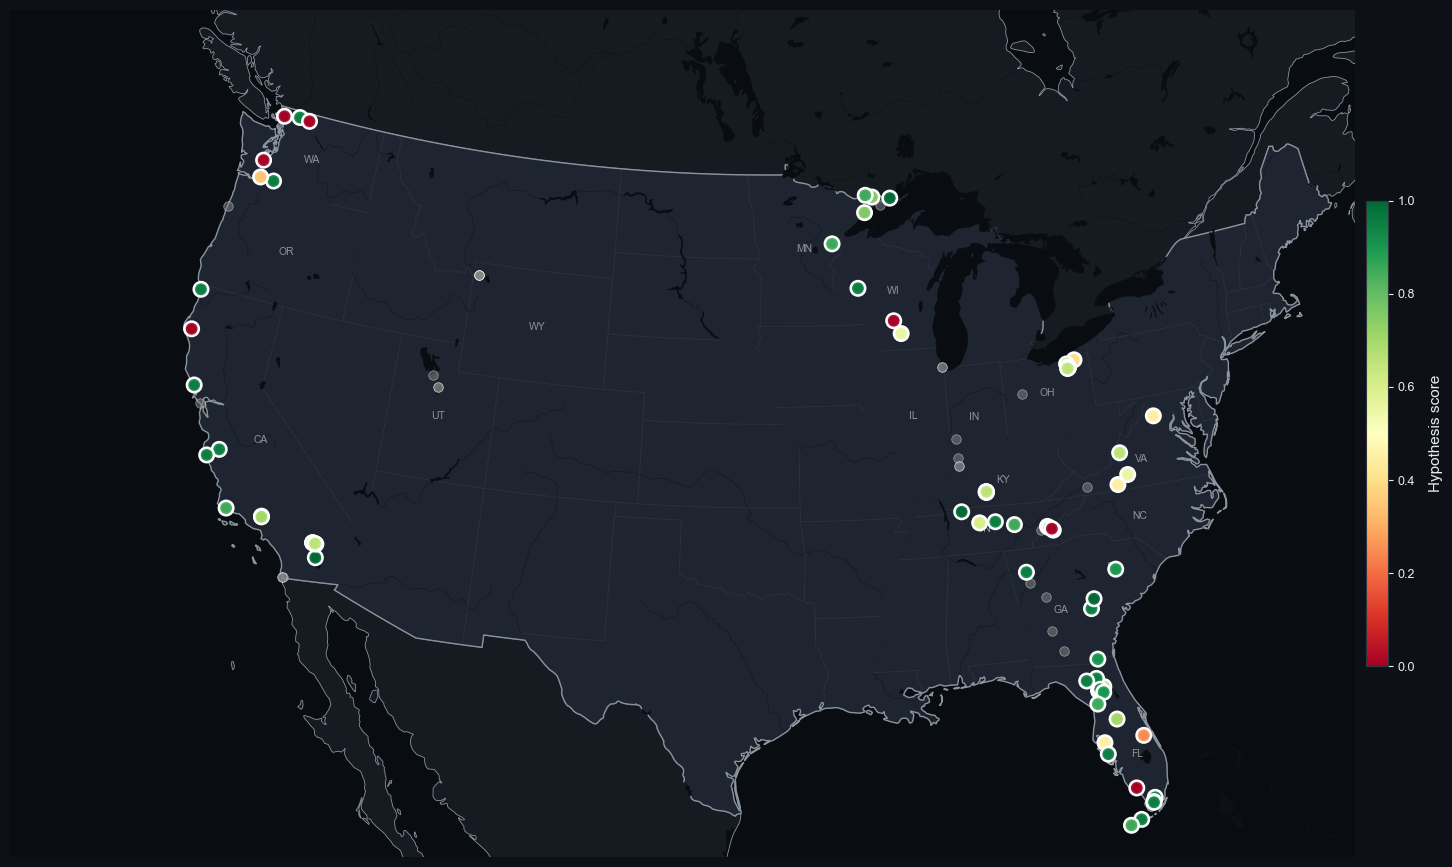

In [87]:
# CONUS bounding box in EPSG:5070
XMIN, XMAX = -3.05e6, 2.35e6
YMIN, YMAX =  1.5e5,  3.55e6

plt.rcParams.update({
    "font.family":    "Arial",
    "axes.facecolor": T["bg_ax"],
    "figure.facecolor": T["bg_fig"],
})

fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor(T["bg_fig"])
ax.set_facecolor(T["bg_ax"])
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)
ax.set_aspect("equal")
ax.set_axis_off()

# ── Geographic base layers ─────────────────────────────────────────────────
ocean_p.plot(ax=ax, color=T["ocean"], zorder=0)

na_context_p[na_context_p["ADMIN"] != "United States of America"].plot(
    ax=ax, color=T["neighbor"], edgecolor=T["country_edge"], linewidth=0.6, zorder=1
)
us_states_p.plot(ax=ax, color=T["land"], edgecolor=T["state_edge"], linewidth=0.5, zorder=2)

# Rivers (subtle blue lines for major rivers)
rivers_p.plot(ax=ax, color=T["river"], linewidth=0.4, alpha=0.6, zorder=3)

# Country border (slightly thicker than state borders)
na_context_p[na_context_p["ADMIN"] == "United States of America"].boundary.plot(
    ax=ax, color=T["country_edge"], linewidth=1.0, zorder=4
)
lakes_p.plot(ax=ax, color=T["lake"], edgecolor=T["lake"], linewidth=0.3, zorder=4)

# ── State abbreviation labels ──────────────────────────────────────────────
if SHOW_STATE_LABELS:
    for _, row in state_labels.iterrows():
        if XMIN < row["cx"] < XMAX and YMIN < row["cy"] < YMAX:
            ax.text(
                row["cx"], row["cy"], row["abbrev"],
                fontsize=7.5, ha="center", va="center",
                color=T["text"], alpha=0.55, fontfamily="Arial",
                fontweight="normal", zorder=5,
            )

# ── Sample points ──────────────────────────────────────────────────────────
GLOW = [pe.withStroke(linewidth=3, foreground="white")] if STYLE == "dark" else []

if ENCODING == "type":
    for wtype, color in TYPE_COLORS.items():
        sub = gdf_p[gdf_p["Type"] == wtype]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub.geometry.x, sub.geometry.y,
            color=color, s=POINT_SIZE, alpha=POINT_ALPHA,
            edgecolors="white", linewidths=0.7, zorder=10, label=wtype,
            path_effects=GLOW,
        )

elif ENCODING == "expedition":
    for exp_id, color in EXPEDITION_COLORS.items():
        sub = gdf_p[gdf_p["Expedition"] == exp_id]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub.geometry.x, sub.geometry.y,
            color=color, s=POINT_SIZE, alpha=POINT_ALPHA,
            edgecolors="white", linewidths=0.7, zorder=10,
            label=EXPEDITION_LABELS[exp_id],
            path_effects=GLOW,
        )

elif ENCODING == "hypothesis":
    hypothesis_gdf = _prepare_hypothesis_scores(gdf_p, HYPOTHESIS_FILE)
    if hypothesis_gdf is None:
        raise ValueError("Set HYPOTHESIS_FILE to a valid text file when ENCODING='hypothesis'.")

    if "Hypothesis" not in hypothesis_gdf.columns:
        hypothesis_gdf["Hypothesis"] = np.nan

    print("hypothesis_gdf columns:", list(hypothesis_gdf.columns))
    print(hypothesis_gdf[["SampleID", "Hypothesis"]].head().to_string(index=False))

    valid = hypothesis_gdf[hypothesis_gdf["Hypothesis"].notna()].copy()
    missing = hypothesis_gdf[hypothesis_gdf["Hypothesis"].isna()].copy()

    cmap = plt.colormaps[HYPOTHESIS_CMAP]
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

    if len(missing) > 0:
        ax.scatter(
            missing.geometry.x, missing.geometry.y,
            color="#888888", s=POINT_SIZE * 0.55, alpha=0.5,
            edgecolors="white", linewidths=0.5, zorder=9, label="No hypothesis score",
        )

    ax.scatter(
        valid.geometry.x, valid.geometry.y,
        c=valid["Hypothesis"], cmap=cmap, norm=norm,
        s=POINT_SIZE, alpha=POINT_ALPHA,
        edgecolors="white", linewidths=0.7, zorder=10,
        path_effects=GLOW,
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm, ax=ax, orientation="vertical",
        fraction=0.022, pad=0.008, shrink=0.55, aspect=22,
    )
    cbar.set_label("Hypothesis score", fontsize=11, color=T["text"], fontfamily="Arial", labelpad=10)
    cbar.ax.yaxis.set_tick_params(color=T["text"], labelsize=9)
    cbar.outline.set_edgecolor(T["spine"])
    plt.setp(cbar.ax.get_yticklabels(), color=T["text"])
    cbar.ax.set_facecolor(T["bg_fig"])

else:  # continuous encodings
    col, cmap_name, cbar_label, *_fixed = CONTINUOUS[ENCODING]
    fixed_range = _fixed[0] if _fixed else None
    valid   = gdf_p[gdf_p[col].notna()].copy()
    missing = gdf_p[gdf_p[col].isna()].copy()

    cmap = plt.colormaps[cmap_name]
    if fixed_range:
        vmin, vmax = fixed_range
    else:
        vmin, vmax = valid[col].min(), valid[col].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    ax.scatter(
        valid.geometry.x, valid.geometry.y,
        c=valid[col], cmap=cmap, norm=norm,
        s=POINT_SIZE, alpha=POINT_ALPHA,
        edgecolors="white", linewidths=0.7, zorder=10,
        path_effects=GLOW,
    )
    if len(missing) > 0:
        ax.scatter(
            missing.geometry.x, missing.geometry.y,
            color="#888888", s=POINT_SIZE * 0.55, alpha=0.5,
            edgecolors="white", linewidths=0.5, zorder=10, label="No data",
        )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm, ax=ax, orientation="vertical",
        fraction=0.022, pad=0.008, shrink=0.55, aspect=22,
    )
    cbar.set_label(cbar_label, fontsize=11, color=T["text"],
                   fontfamily="Arial", labelpad=10)
    cbar.ax.yaxis.set_tick_params(color=T["text"], labelsize=9)
    cbar.outline.set_edgecolor(T["spine"])
    plt.setp(cbar.ax.get_yticklabels(), color=T["text"])
    cbar.ax.set_facecolor(T["bg_fig"])

# ── Legend (categorical encodings) ────────────────────────────────────────
if ENCODING in ("type", "expedition"):
    legend = ax.legend(
        title=("Water Body Type" if ENCODING == "type" else "Field Expedition"),
        title_fontsize=12,
        fontsize=11,
        loc="lower center",
        frameon=True,
        framealpha=0.92,
        edgecolor=T["legend_edge"],
        facecolor=T["legend_face"],
        markerscale=0.95,
        ncols=(2 if ENCODING == "type" else 1),
        columnspacing=0.7,
        handlelength=0.75,
        handleheight=0.75,
        labelspacing=0.45,
        borderpad=0.75,
    )
    legend.get_title().set_color(T["legend_text"])
    legend.get_title().set_fontfamily("Arial")
    legend.get_title().set_fontweight("bold")
    for txt in legend.get_texts():
        txt.set_color(T["legend_text"])
        txt.set_fontfamily("Arial")

elif ENCODING in ("temperature", "ph", "salinity", "altitude") and len(missing) > 0:
    # Just the "no data" marker
    legend = ax.legend(
        fontsize=9, loc="lower right",
        frameon=True, framealpha=0.88,
        edgecolor=T["legend_edge"], facecolor=T["legend_face"],
    )
    for txt in legend.get_texts():
        txt.set_color(T["legend_text"])

# ── Scale bar ──────────────────────────────────────────────────────────────
# if SHOW_SCALEBAR:
#     # 500 km bar placed in lower-left corner
#     bar_km   = 500
#     bar_m    = bar_km * 1000
#     bar_x0   = XMIN + (XMAX - XMIN) * 0.05
#     bar_y0   = YMIN + (YMAX - YMIN) * 0.055
#     bar_x1   = bar_x0 + bar_m
#     bar_h    = (YMAX - YMIN) * 0.008

#     ax.fill_between([bar_x0, bar_x0 + bar_m / 2], bar_y0, bar_y0 + bar_h,
#                     color=T["scalebar"], zorder=12)
#     ax.fill_between([bar_x0 + bar_m / 2, bar_x1], bar_y0, bar_y0 + bar_h,
#                     color=T["bg_ax"] if STYLE == "light" else "#444444", zorder=12)
#     for x in [bar_x0, bar_x0 + bar_m / 2, bar_x1]:
#         ax.plot([x, x], [bar_y0, bar_y0 + bar_h], color=T["scalebar"],
#                 linewidth=0.8, zorder=13)
#     ax.text(bar_x0,                bar_y0 - bar_h * 0.8, "0",    fontsize=8,
#             ha="center

---
## Optional: Side-by-side encoding comparison

Run the cell below to render **all six encodings** in a single figure for quick comparison.


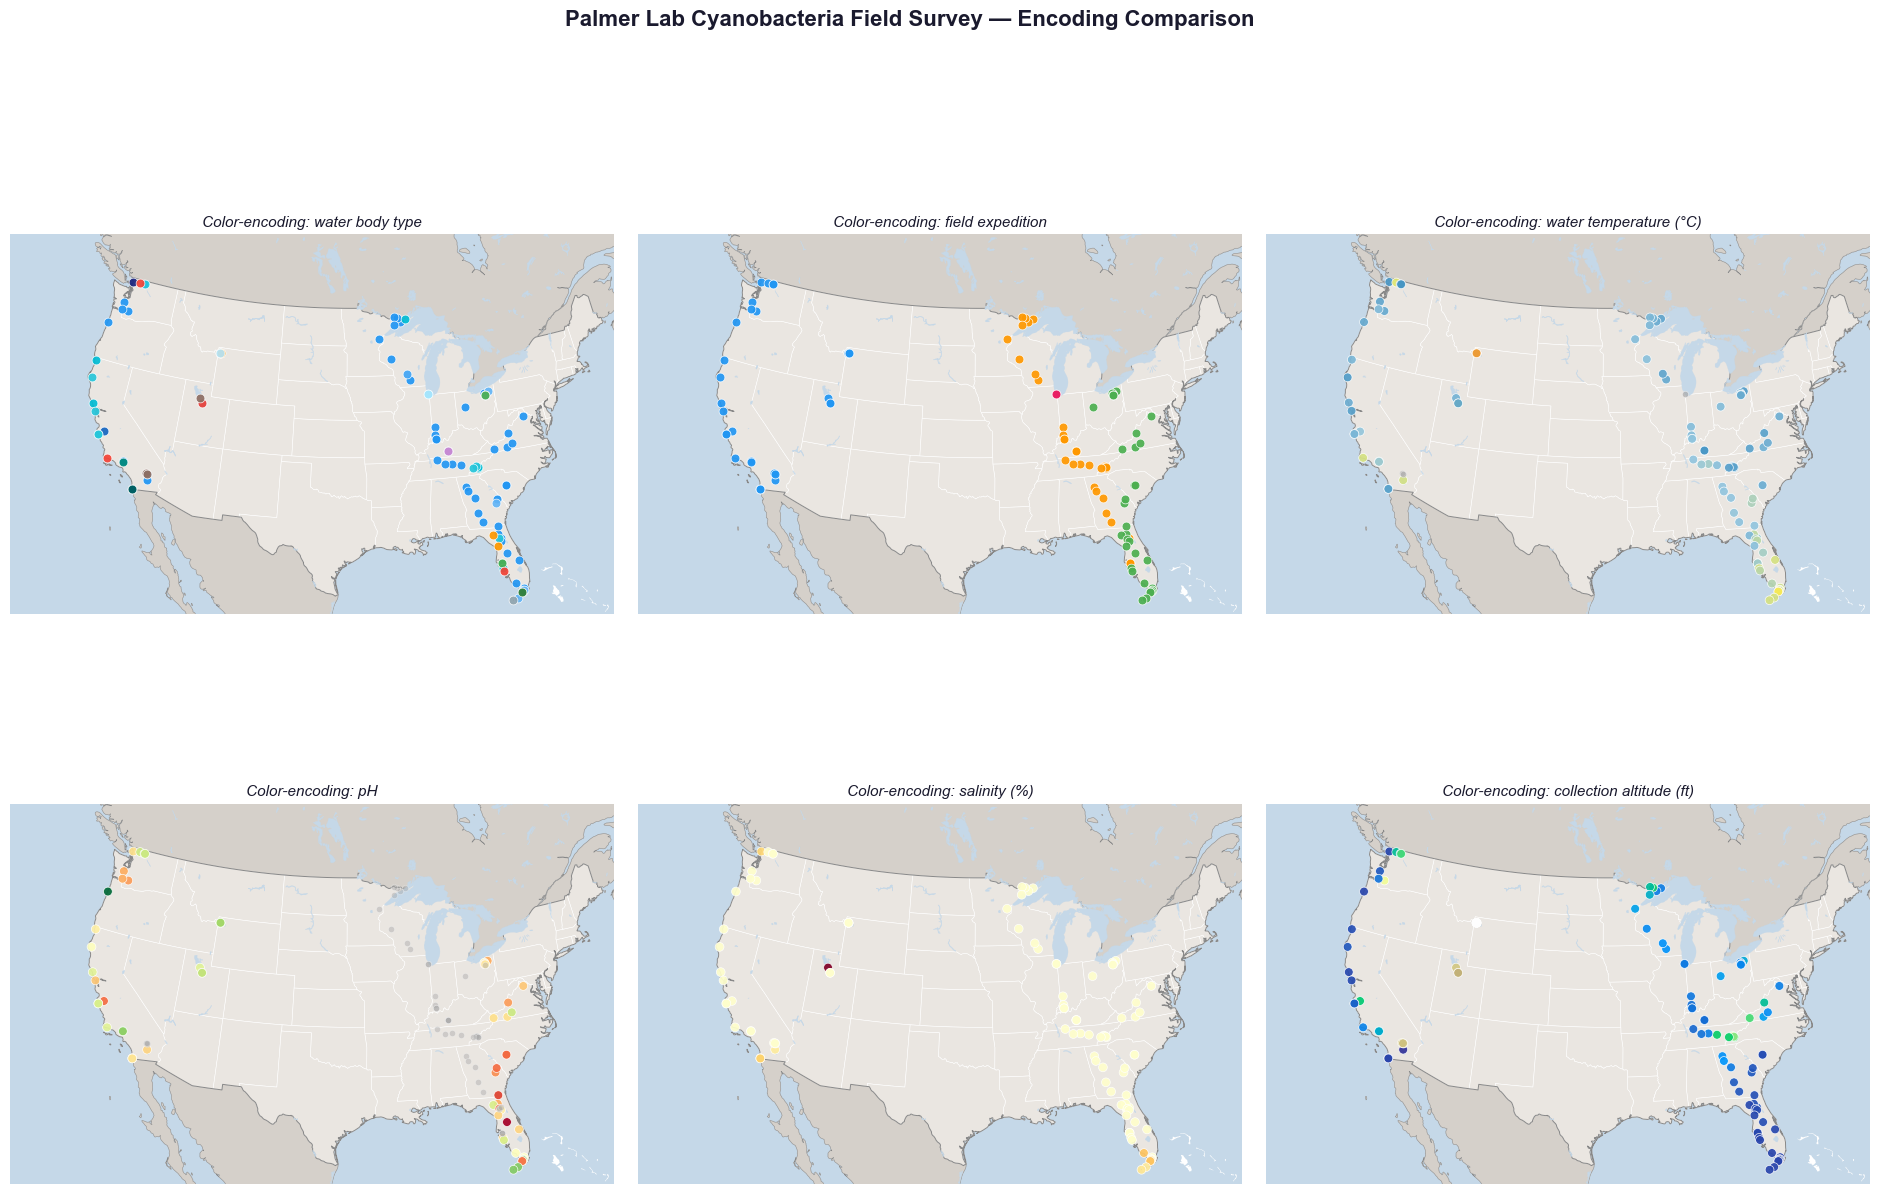

In [88]:
# Renders a 2×3 grid comparing all encodings in light style
# This cell is independent — you don't need to re-run the map above

from itertools import product

ENCODINGS_ALL = ["type", "expedition", "temperature", "ph", "salinity", "altitude"]

fig, axes = plt.subplots(2, 3, figsize=(24, 14),
                         facecolor="white", gridspec_kw={"hspace": 0.12, "wspace": 0.04})

_T = dict(  # always light style for comparison grid
    bg_fig="#FFFFFF", bg_ax="#EEF2F5", land="#EAE6E1", neighbor="#D5D0CA",
    ocean="#C5D8E8", state_edge="white", country_edge="#888888",
    lake="#C5D8E8", river="#A8C8DC", text="#1A1A2E", spine="#CCCCCC",
    title="#1A1A2E", legend_face="white", legend_edge="#CCCCCC",
    legend_text="#333333", grid="#E0E0E0", scalebar="#444444",
)

for ax_i, enc in zip(axes.flat, ENCODINGS_ALL):
    ax_i.set_facecolor(_T["bg_ax"])
    ax_i.set_xlim(XMIN, XMAX); ax_i.set_ylim(YMIN, YMAX)
    ax_i.set_aspect("equal"); ax_i.set_axis_off()

    ocean_p.plot(ax=ax_i, color=_T["ocean"], zorder=0)
    na_context_p[na_context_p["ADMIN"] != "United States of America"].plot(
        ax=ax_i, color=_T["neighbor"], edgecolor=_T["country_edge"], linewidth=0.4, zorder=1)
    us_states_p.plot(ax=ax_i, color=_T["land"], edgecolor=_T["state_edge"], linewidth=0.4, zorder=2)
    na_context_p[na_context_p["ADMIN"] == "United States of America"].boundary.plot(
        ax=ax_i, color=_T["country_edge"], linewidth=0.7, zorder=3)
    lakes_p.plot(ax=ax_i, color=_T["lake"], edgecolor=_T["lake"], linewidth=0.2, zorder=3)

    _SZ = 40

    if enc == "type":
        for wtype, color in TYPE_COLORS.items():
            sub = gdf_p[gdf_p["Type"] == wtype]
            if len(sub): ax_i.scatter(sub.geometry.x, sub.geometry.y,
                color=color, s=_SZ, alpha=0.92, edgecolors="white", linewidths=0.5, zorder=10)

    elif enc == "expedition":
        for eid, color in EXPEDITION_COLORS.items():
            sub = gdf_p[gdf_p["Expedition"] == eid]
            if len(sub): ax_i.scatter(sub.geometry.x, sub.geometry.y,
                color=color, s=_SZ, alpha=0.92, edgecolors="white", linewidths=0.5, zorder=10)

    else:
        col, cmap_name, _, *_fixed = CONTINUOUS[enc]
        fixed_range = _fixed[0] if _fixed else None
        valid = gdf_p[gdf_p[col].notna()]
        if len(valid):
            _vmin, _vmax = fixed_range if fixed_range else (valid[col].min(), valid[col].max())
            norm = mcolors.Normalize(vmin=_vmin, vmax=_vmax)
            ax_i.scatter(valid.geometry.x, valid.geometry.y,
                c=valid[col], cmap=plt.colormaps[cmap_name], norm=norm,
                s=_SZ, alpha=0.92, edgecolors="white", linewidths=0.5, zorder=10)
        missing = gdf_p[gdf_p[col].isna()]
        if len(missing): ax_i.scatter(missing.geometry.x, missing.geometry.y,
            color="#AAAAAA", s=_SZ*0.5, alpha=0.45,
            edgecolors="white", linewidths=0.4, zorder=10)

    ax_i.set_title(ENC_SUBTITLES[enc], fontsize=11, color=_T["title"],
                   fontfamily="Arial", fontstyle="italic", pad=6)

fig.suptitle("Palmer Lab Cyanobacteria Field Survey — Encoding Comparison",
             fontsize=16, fontweight="bold", color=_T["title"],
             fontfamily="Arial", y=0.995)
plt.show()
